# Training Results

Two-phase training: softmax warmup (Phase 1) followed by semi-hard triplet (Phase 2).

Charts: train loss, in-loop LFW accuracy, spread (`pos_sim - neg_sim`), and t-SNE projection of validation embeddings from `best.pt`.

In [1]:
import json, sys
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

hist = json.loads((ROOT / 'training_pipeline/checkpoints/history.json').read_text())
n_p1 = sum(1 for p in hist['phase'] if p == 1)
n_p2 = sum(1 for p in hist['phase'] if p == 2)
best_epoch = int(max(range(len(hist['lfw_acc'])), key=lambda i: hist['lfw_acc'][i]))
print(f'Phase 1 epochs:       {n_p1}')
print(f'Phase 2 epochs:       {n_p2}')
print(f'Best LFW (in-loop):   {max(hist["lfw_acc"]):.4f}  @ epoch {best_epoch + 1} (phase {hist["phase"][best_epoch]})')
print(f'Best spread:          {max(hist["spread"]):.4f}')
print(f'Final train loss:     {hist["train_loss"][-1]:.4f}')

Phase 1 epochs:       3
Phase 2 epochs:       17
Best LFW (in-loop):   0.9090  @ epoch 4 (phase 2)
Best spread:          0.5845
Final train loss:     0.6867


## Model summary

In [2]:
import torch
from training_pipeline.src.model import FaceEmbedding

device = 'cuda' if torch.cuda.is_available() else 'cpu'
ckpt = torch.load(ROOT / 'application/models/best.pt', map_location=device, weights_only=False)
model = FaceEmbedding(embedding_dim=ckpt['cfg']['train']['embedding_dim'], pretrained=False).to(device).eval()
model.load_state_dict(ckpt['model'])

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {n_params:,}')
print(f'Trainable parameters: {n_trainable:,}')
print(f'Embedding dim:        {ckpt["cfg"]["train"]["embedding_dim"]}')
print(f'Phase-2 loss:         softplus(d_ap - d_an), semi-hard mining, margin={ckpt["cfg"]["train"]["margin"]}')
print()
print(model)

Total parameters:     24,557,120
Trainable parameters: 24,557,120
Embedding dim:        512
Phase-2 loss:         softplus(d_ap - d_an), semi-hard mining, margin=0.3

FaceEmbedding(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
 

## Per-epoch log

In [3]:
import pandas as pd

log = pd.DataFrame({
    'epoch': range(1, len(hist['train_loss']) + 1),
    'phase': hist['phase'],
    'train_loss': hist['train_loss'],
    'lfw_acc_inloop': hist['lfw_acc'],
    'spread': hist['spread'],
})
log

,epoch,phase,train_loss,lfw_acc_inloop,spread
0,1,1,7.443102,0.872500,0.417551
1,2,1,3.133032,0.898833,0.446352
2,3,1,1.747332,0.893667,0.447259
3,4,2,0.582424,0.909000,0.584543
4,5,2,0.567747,0.898667,0.575914
5,6,2,0.551128,0.897833,0.576634
6,7,2,0.533337,0.882500,0.558207
7,8,2,0.515122,0.877667,0.539141
8,9,2,0.496996,0.854833,0.506198
9,10,2,0.479040,0.858000,0.510269


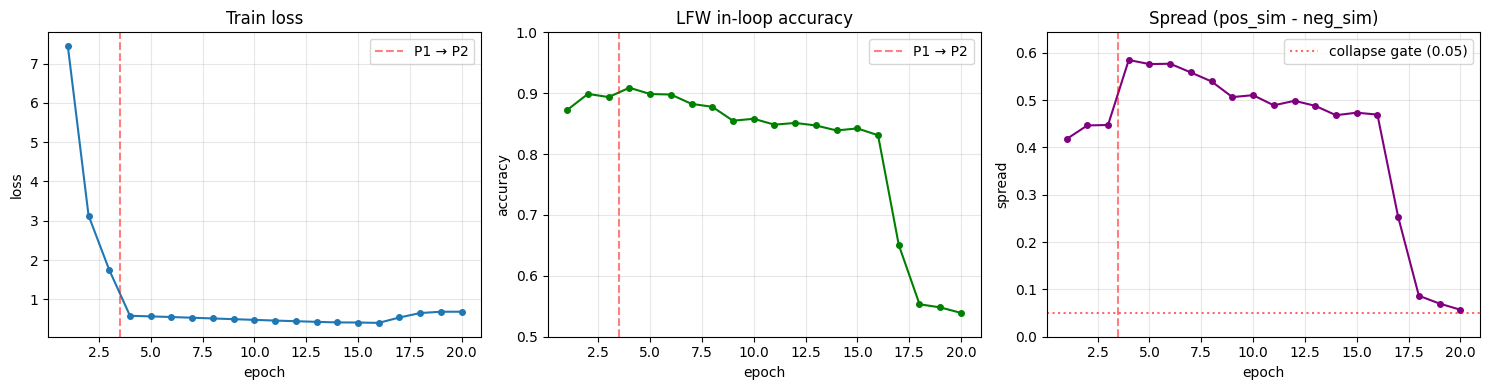

In [4]:
# Train loss + LFW acc + spread, with phase boundary annotated.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, len(hist['train_loss']) + 1)
phase_boundary = n_p1 + 0.5

axes[0].plot(epochs, hist['train_loss'], marker='o', markersize=4)
axes[0].axvline(phase_boundary, c='red', ls='--', alpha=0.5, label='P1 → P2')
axes[0].set_title('Train loss'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, hist['lfw_acc'], marker='o', markersize=4, c='green')
axes[1].axvline(phase_boundary, c='red', ls='--', alpha=0.5, label='P1 → P2')
axes[1].set_title('LFW in-loop accuracy'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0.5, 1.0); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, hist['spread'], marker='o', markersize=4, c='purple')
axes[2].axvline(phase_boundary, c='red', ls='--', alpha=0.5)
axes[2].axhline(0.05, c='red', ls=':', alpha=0.6, label='collapse gate (0.05)')
axes[2].set_title('Spread (pos_sim - neg_sim)'); axes[2].set_xlabel('epoch'); axes[2].set_ylabel('spread')
axes[2].set_ylim(0, max(hist['spread']) * 1.1); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## t-SNE projection of validation embeddings

Sample 1000 validation images, compute embeddings, project to 2D. Color by identity (mod 20).

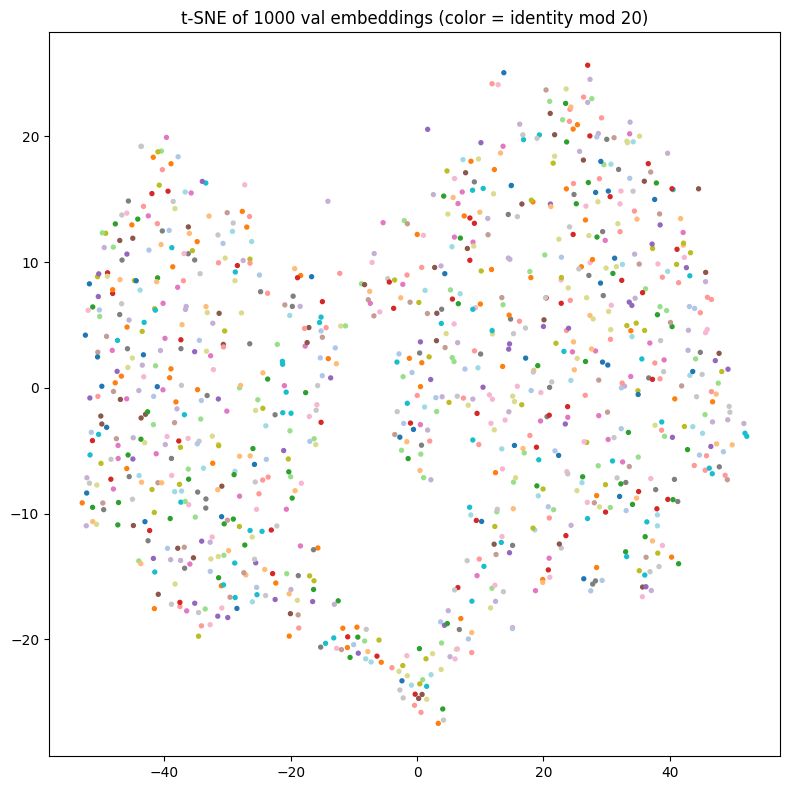

In [5]:
import numpy as np
from sklearn.manifold import TSNE
from training_pipeline.src.dataset import FaceDataset, eval_transform

ds = FaceDataset(ROOT / 'process-data/manifest.parquet', split='val', transform=eval_transform())
n_sample = min(1000, len(ds))
idxs = np.random.RandomState(0).choice(len(ds), size=n_sample, replace=False)
imgs = torch.stack([ds[int(i)][0] for i in idxs]).to(device)
labels = np.array([ds[int(i)][1] for i in idxs])

with torch.no_grad():
    emb = model.embed_normalized(imgs).cpu().numpy()

z = TSNE(n_components=2, random_state=0, perplexity=30, init='pca').fit_transform(emb)
plt.figure(figsize=(8, 8))
plt.scatter(z[:, 0], z[:, 1], c=labels % 20, s=8, cmap='tab20')
plt.title(f't-SNE of {n_sample} val embeddings (color = identity mod 20)')
plt.tight_layout(); plt.show()

In [6]:
# Hyperparameters used.
cfg = ckpt['cfg']
tbl = {**cfg['train'], 'eval_max_pairs_inloop': cfg['eval']['max_pairs_inloop']}
pd.DataFrame(tbl.items(), columns=['param', 'value'])

,param,value
0,phase1_epochs,3.0000
1,phase2_epochs,17.0000
2,batches_per_epoch,1500.0000
3,phase1_batch_size,128.0000
4,p,32.0000
5,k,4.0000
6,margin,0.3000
7,lr_head,0.0005
8,lr_backbone,0.0001
9,weight_decay,0.0005
